# 04 — Avaliação e Interpretação

O modelo e o ponto de corte foram fixados no notebook 03 usando apenas o treino. Aqui eles são aplicados, uma única vez, ao conjunto de teste: contas de proponentes que o modelo nunca viu.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
)

from src.config import DATA_PROCESSED, GROUP, METRICS, MODELS, RANDOM_STATE, TARGET  # semente fixa: 42
from src.evaluation import bootstrap_auc, save_table, score
from src.viz import AZUIS, AZUL, CINZA, LARANJA, save, set_style

set_style()
pd.set_option("display.max_columns", None)
print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


In [2]:
pacote = joblib.load(MODELS / "melhor_modelo.joblib")
modelo, LIMIAR, FEATURES = pacote["modelo"], pacote["limiar"], pacote["features"]

treino = pd.read_csv(DATA_PROCESSED / "treino.csv")
teste = pd.read_csv(DATA_PROCESSED / "teste.csv")
X_test, y_test = teste[FEATURES], teste[TARGET]

print(f"Modelo: {pacote['nome']} | corte definido no treino: {LIMIAR:.2f}")
print(f"Teste: {len(teste):,} contas de {teste[GROUP].nunique():,} proponentes | {int(y_test.sum())} más ({y_test.mean():.2%})")

Modelo: Regressão Logística | corte definido no treino: 0.84
Teste: 5,644 contas de 1,737 proponentes | 94 más (1.67%)


## 1. Métricas no conjunto de teste

In [3]:
proba = modelo.predict_proba(X_test)[:, 1]
pred = (proba >= LIMIAR).astype(int)

metricas = pd.DataFrame({
    "Corte 0,50": score(y_test, proba, 0.5),
    f"Corte {LIMIAR:.2f} (definido no treino)": score(y_test, proba, LIMIAR),
}).T.round(4)
display(save_table(metricas, "metricas_teste"))

ic = bootstrap_auc(y_test, proba)
print(f"ROC-AUC no teste: {metricas['roc_auc'].iloc[0]:.3f} (intervalo de 95% por bootstrap: {ic[0]:.3f} a {ic[1]:.3f})")
print(f"Referências: acaso = 0,500 | PR-AUC de um modelo sem informação = taxa de maus = {y_test.mean():.4f}\n")
print(classification_report(y_test, pred, target_names=["Bom pagador", "Mau pagador"], digits=3))

,roc_auc,pr_auc,mcc,f1,recall,precision,accuracy
"Corte 0,50",0.7116,0.0886,0.0884,0.0614,0.6702,0.0322,0.6588
Corte 0.84 (definido no treino),0.7116,0.0886,0.1637,0.1754,0.1596,0.1948,0.9750


ROC-AUC no teste: 0.712 (intervalo de 95% por bootstrap: 0.653 a 0.767)
Referências: acaso = 0,500 | PR-AUC de um modelo sem informação = taxa de maus = 0.0167

              precision    recall  f1-score   support

 Bom pagador      0.986     0.989     0.987      5550
 Mau pagador      0.195     0.160     0.175        94

    accuracy                          0.975      5644
   macro avg      0.590     0.574     0.581      5644
weighted avg      0.973     0.975     0.974      5644



**ROC-AUC de 0,712 no teste**, com intervalo de 95% de 0,653 a 0,767. Na validação cruzada o valor era 0,749; a queda de 0,04 é da mesma ordem da variação entre folds (0,03). O intervalo é largo porque o teste tem só 94 contas más: a estimativa pontual está acima de 0,70, mas o limite inferior não, e é assim que o resultado deve ser comunicado.

O PR-AUC de 0,089 é 5,3 vezes a taxa de maus da base (0,0167), que é o que um modelo sem informação obteria.

No corte de 0,84, definido no treino: MCC de 0,164, precisão de 19,5% e recall de 16,0%. As previsões *out-of-fold* do treino indicavam 0,187, 25,9% e 14,7%: o comportamento se manteve em dados novos, com uma pequena perda de precisão.

A acurácia nesse corte é 97,5%, **menor** que os 98,3% de quem aprova todo mundo. É o exemplo mais claro de por que ela não é usada aqui.

## 2. Justificativa das métricas

**Por que não acurácia.** Com 1,67% de maus no teste, aprovar todos os pedidos dá 98,3% de acurácia sem evitar nenhum calote. A acurácia premia exatamente o comportamento que não tem valor.

**Métricas priorizadas:**

- **ROC-AUC**, para escolher o modelo. Mede a chance de um mau pagador receber score maior que um bom, sem depender de corte nem da proporção das classes. É o que importa para ordenar pedidos por risco.
- **PR-AUC**, como complemento. É mais exigente com a classe rara e tem referência natural: a taxa de maus da base.
- **MCC**, para escolher o corte. Usa as quatro células da matriz de confusão e só é alto quando o modelo vai bem nas duas classes, o que o torna confiável em bases desbalanceadas.
- **Precisão e recall**, para traduzir o corte em operação: de cada 100 sinalizados, quantos eram maus; de cada 100 maus, quantos foram sinalizados.

**Qual erro custa mais.** Aprovar um mau pagador (falso negativo) custa o saldo não pago. Recusar um bom (falso positivo) custa a margem que ele geraria, um valor bem menor por cliente. Mas bons pagadores são 60 vezes mais numerosos: um corte que recuse muitos deles destrói mais receita do que a inadimplência evitada. A base não traz valores de limite nem de perda, então não é possível calcular o corte de maior lucro; o MCC é usado como critério de equilíbrio, e a seção de faixas de risco mostra uma forma de uso que não depende de um corte único.

## 3. Matriz de confusão

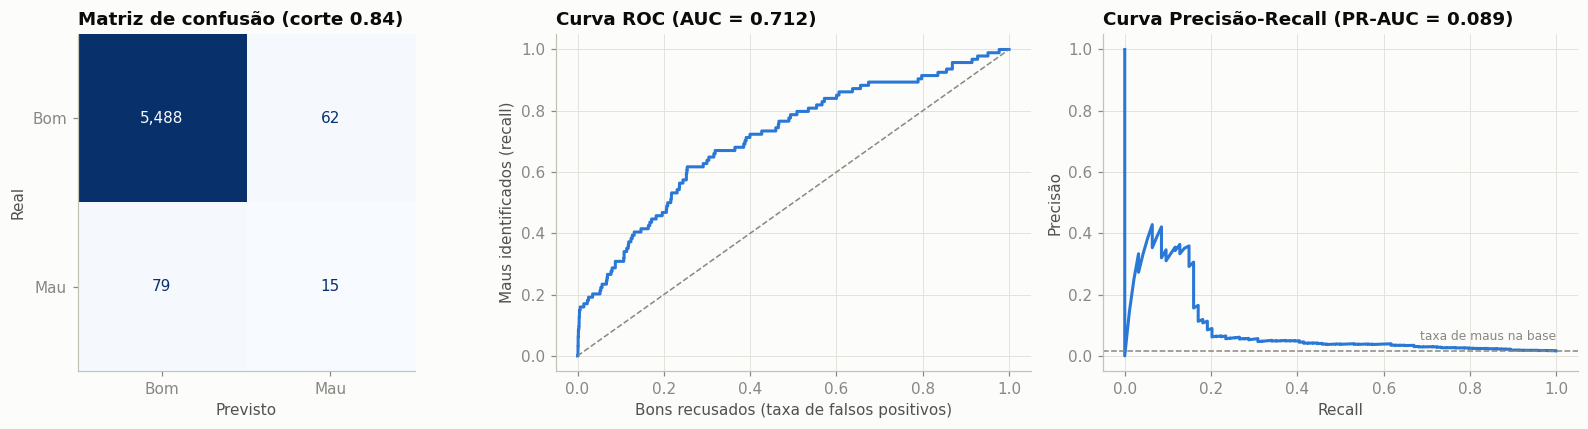

Maus identificados: 15 de 94 | maus aprovados: 79
Bons recusados: 62 de 5,550 (1.1%) | contas sinalizadas: 77 (1.4% do total)
Para cada mau identificado, 4 bons são sinalizados.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["Bom", "Mau"]).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format=",")
axes[0].set_title(f"Matriz de confusão (corte {LIMIAR:.2f})")
axes[0].set_xlabel("Previsto")
axes[0].set_ylabel("Real")
axes[0].grid(False)

fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color=AZUL)
axes[1].plot([0, 1], [0, 1], color=CINZA, linewidth=1, linestyle="--")
axes[1].set_title(f"Curva ROC (AUC = {metricas['roc_auc'].iloc[0]:.3f})")
axes[1].set_xlabel("Bons recusados (taxa de falsos positivos)")
axes[1].set_ylabel("Maus identificados (recall)")

prec, rec, _ = precision_recall_curve(y_test, proba)
axes[2].plot(rec, prec, color=AZUL)
axes[2].axhline(y_test.mean(), color=CINZA, linewidth=1, linestyle="--")
axes[2].text(1.0, y_test.mean() + 0.035, "taxa de maus na base", color=CINZA, fontsize=8, ha="right")
axes[2].set_title(f"Curva Precisão-Recall (PR-AUC = {metricas['pr_auc'].iloc[0]:.3f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precisão")
plt.tight_layout()
save(fig, "04_matriz_roc_pr")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Maus identificados: {tp} de {tp + fn} | maus aprovados: {fn}")
print(f"Bons recusados: {fp:,} de {tn + fp:,} ({fp / (tn + fp):.1%}) | contas sinalizadas: {tp + fp:,} ({(tp + fp) / len(y_test):.1%} do total)")
print(f"Para cada mau identificado, {fp / tp:.0f} bons são sinalizados.")

No corte de 0,84 o modelo sinaliza 77 contas (1,4% do total). Dessas, 15 são de fato más: **1 em cada 5 sinalizadas**, contra 1 em cada 60 na base. É uma concentração de risco 12 vezes maior, com apenas 62 bons clientes afetados (1,1% dos bons).

O outro lado: 79 dos 94 maus pagadores passam sem sinalização. O corte isola um grupo pequeno de risco muito alto, mas não resolve sozinho a inadimplência. A curva ROC mostra que, para capturar mais maus, é preciso aceitar recusar proporcionalmente muito mais bons; a curva de precisão-recall mostra que a precisão cai rapidamente depois dos primeiros 15% de recall.

### Faixas de risco

Uma política de crédito raramente é um único corte. Ordenamos as contas de teste pela probabilidade prevista e as dividimos em cinco faixas de mesmo tamanho.

,contas,maus,taxa_maus,%_dos_maus
faixa,,,,
1 (menor risco),1129,8,0.0071,0.0851
2,1129,7,0.0062,0.0745
3,1128,12,0.0106,0.1277
4,1129,24,0.0213,0.2553
5 (maior risco),1129,43,0.0381,0.4574


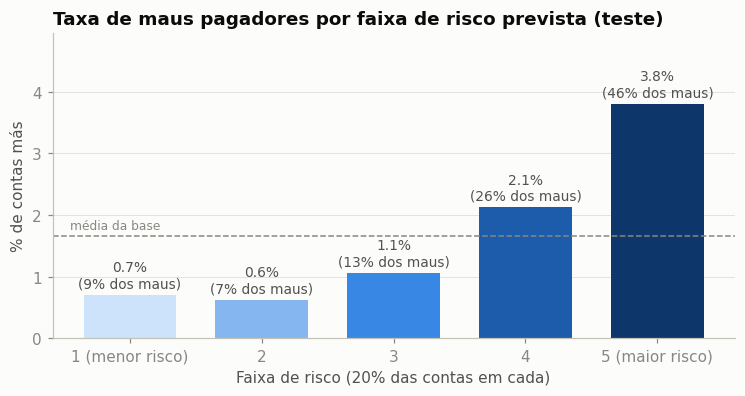

In [5]:
faixa = pd.qcut(pd.Series(proba).rank(method="first"), 5, labels=["1 (menor risco)", "2", "3", "4", "5 (maior risco)"])
faixas = pd.DataFrame({"faixa": faixa, "mau": y_test.values}).groupby("faixa", observed=True)["mau"].agg(["size", "sum", "mean"])
faixas.columns = ["contas", "maus", "taxa_maus"]
faixas["%_dos_maus"] = faixas["maus"] / faixas["maus"].sum()
display(save_table(faixas.round(4), "faixas_risco"))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(faixas.index.astype(str), faixas["taxa_maus"] * 100, color=AZUIS, width=0.7)
for x, (v, pct) in enumerate(zip(faixas["taxa_maus"] * 100, faixas["%_dos_maus"])):
    ax.text(x, v + 0.12, f"{v:.1f}%\n({pct:.0%} dos maus)", ha="center", color="#52514e", fontsize=9)
ax.axhline(y_test.mean() * 100, color=CINZA, linewidth=1, linestyle="--")
ax.text(-0.45, y_test.mean() * 100 + 0.1, "média da base", color=CINZA, fontsize=8)
ax.set_ylim(0, faixas["taxa_maus"].max() * 100 * 1.3)
ax.set_title("Taxa de maus pagadores por faixa de risco prevista (teste)")
ax.set_xlabel("Faixa de risco (20% das contas em cada)")
ax.set_ylabel("% de contas más")
ax.grid(axis="x", visible=False)
save(fig, "04_faixas_risco")
plt.show()

- **Faixa 5** (os 20% de maior score): 3,8% de atraso grave, mais que o dobro da média, e **46% de todos os maus pagadores do teste**.
- **Faixa 4:** 2,1%, um pouco acima da média, com 26% dos maus.
- **Faixas 1 a 3:** entre 0,6% e 1,1%. Somadas, são 60% das contas e 0,8% de atraso grave.

As faixas 4 e 5 concentram 71% dos maus em 40% das contas. As três faixas de baixo não se distinguem entre si (a faixa 1 tem taxa ligeiramente maior que a 2): o modelo separa bem o topo do risco, e pouco dentro do grupo de baixo risco.

## 4. Importância das variáveis

Usamos importância por permutação no teste: embaralha-se uma variável por vez e mede-se quanto o ROC-AUC cai. Funciona para qualquer modelo e mede o efeito na previsão de dados novos.

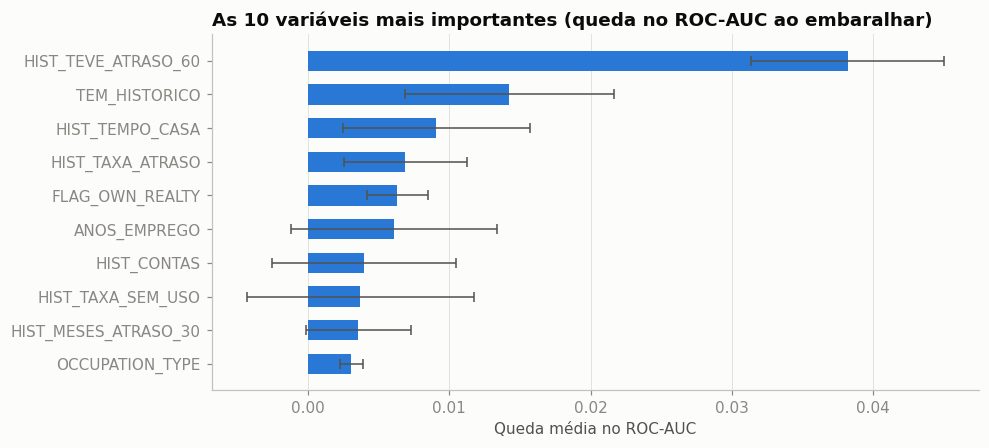

,queda_auc,desvio
HIST_TEVE_ATRASO_60,0.0382,0.0068
TEM_HISTORICO,0.0142,0.0074
HIST_TEMPO_CASA,0.0091,0.0066
HIST_TAXA_ATRASO,0.0069,0.0044
FLAG_OWN_REALTY,0.0063,0.0021
ANOS_EMPREGO,0.0061,0.0073
HIST_CONTAS,0.0040,0.0065
HIST_TAXA_SEM_USO,0.0037,0.0080
HIST_MESES_ATRASO_30,0.0036,0.0037
OCCUPATION_TYPE,0.0031,0.0008


Soma das quedas — variáveis de histórico: 0.081 | variáveis de formulário: 0.011


In [6]:
perm = permutation_importance(modelo, X_test, y_test, scoring="roc_auc", n_repeats=20,
                              random_state=RANDOM_STATE, n_jobs=1)
importancia = pd.DataFrame({"queda_auc": perm.importances_mean, "desvio": perm.importances_std},
                           index=FEATURES).sort_values("queda_auc", ascending=False)
save_table(importancia.round(4), "importancia_permutacao")

top = importancia.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(top.index, top["queda_auc"], xerr=top["desvio"], color=AZUL, height=0.6,
        error_kw={"ecolor": "#52514e", "elinewidth": 1, "capsize": 3})
ax.set_title("As 10 variáveis mais importantes (queda no ROC-AUC ao embaralhar)")
ax.set_xlabel("Queda média no ROC-AUC")
ax.grid(axis="y", visible=False)
save(fig, "04_importancia")
plt.show()

display(importancia.head(10).round(4))
historico = [c for c in FEATURES if c.startswith("HIST_") or c == "TEM_HISTORICO"]
print(f"Soma das quedas — variáveis de histórico: {importancia.loc[historico, 'queda_auc'].sum():.3f} | "
      f"variáveis de formulário: {importancia.drop(historico)['queda_auc'].sum():.3f}")

- **`HIST_TEVE_ATRASO_60`** domina: embaralhar essa variável derruba o ROC-AUC em 0,038. Ter atrasado 60 dias ou mais em um cartão anterior é o principal sinal de risco.
- **`TEM_HISTORICO`** (0,014) e **`HIST_TEMPO_CASA`** (0,009): já ser cliente e há quanto tempo.
- **`HIST_TAXA_ATRASO`** (0,007), a proporção de meses com algum atraso em contas anteriores.
- Do formulário, só aparecem com efeito pequeno **`FLAG_OWN_REALTY`** (0,006), **`ANOS_EMPREGO`** (0,006) e **`OCCUPATION_TYPE`** (0,003).

Somando as quedas: 0,081 para as variáveis de histórico e 0,011 para as de formulário. Faz sentido no domínio: o melhor indicador de como alguém vai pagar é como já pagou.

Cautela na leitura: com 94 contas más, várias dessas importâncias têm desvio do mesmo tamanho do efeito. Estão claramente acima do ruído `HIST_TEVE_ATRASO_60`, `FLAG_OWN_REALTY` e `OCCUPATION_TYPE`; as demais indicam direção, não magnitude.

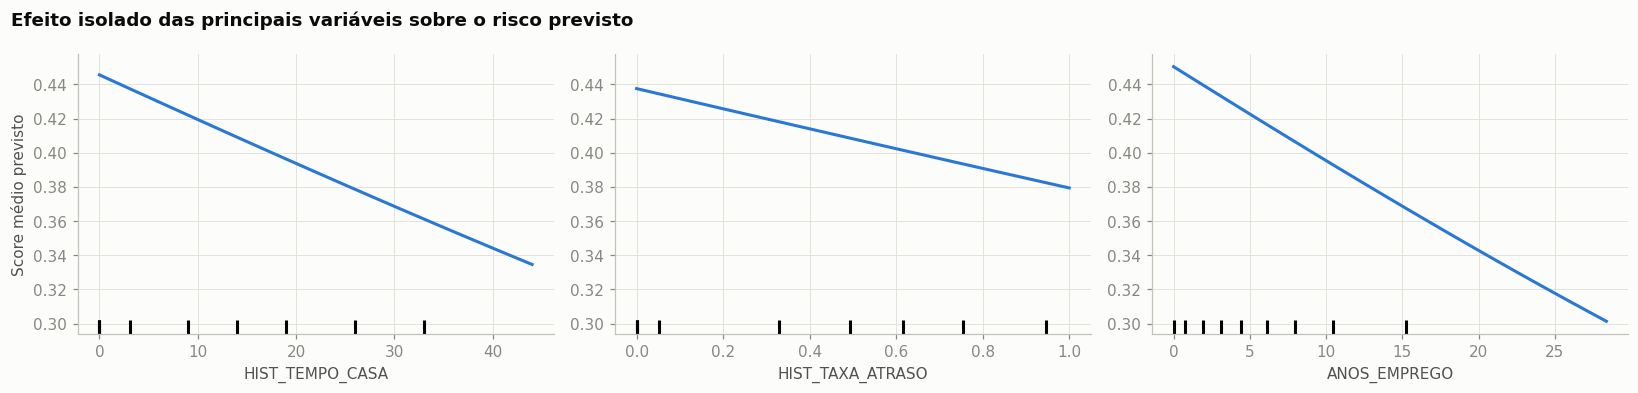

In [7]:
top_numericas = [c for c in importancia.index if teste[c].nunique() > 5 and teste[c].dtype != object][:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
PartialDependenceDisplay.from_estimator(modelo, X_test, top_numericas, ax=axes, grid_resolution=25,
                                        percentiles=(0.01, 0.99), line_kw={"color": AZUL, "linewidth": 2})
for ax in axes:
    ax.set_ylabel("")
axes[0].set_ylabel("Score médio previsto")
fig.suptitle("Efeito isolado das principais variáveis sobre o risco previsto", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
save(fig, "04_dependencia_parcial")
plt.show()

O modelo é linear, então cada efeito é uma reta, e o que importa é a direção:

- **`HIST_TEMPO_CASA`:** quanto mais tempo de relacionamento, menor o score de risco.
- **`ANOS_EMPREGO`:** quanto mais tempo no emprego atual, menor o risco. É a variável de formulário com efeito mais visível.
- **`HIST_TAXA_ATRASO`:** o efeito é negativo, o que parece contraintuitivo. Essa taxa é dominada por atrasos de até 29 dias (`STATUS` 0), que o notebook 02 já mostrou não estarem associados a risco: indicam cartão em uso ativo. Atraso leve frequente não é sinal de alerta; atraso de 60 dias é.

### Onde o modelo funciona e onde não funciona

In [8]:
linhas = {}
for rotulo, mascara in [("Já tinha conta (com histórico)", teste["TEM_HISTORICO"] == 1),
                        ("Primeira conta (sem histórico)", teste["TEM_HISTORICO"] == 0)]:
    s = score(y_test[mascara], proba[mascara], LIMIAR)
    lo, hi = bootstrap_auc(y_test[mascara], proba[mascara])
    linhas[rotulo] = {"contas": int(mascara.sum()), "maus": int(y_test[mascara].sum()),
                      "taxa_maus": y_test[mascara].mean(), "roc_auc": s["roc_auc"],
                      "ic95_inf": lo, "ic95_sup": hi, "recall": s["recall"]}
segmentos = pd.DataFrame(linhas).T.round(4)
display(save_table(segmentos, "segmentos"))

,contas,maus,taxa_maus,roc_auc,ic95_inf,ic95_sup,recall
Já tinha conta (com histórico),3687.0,45.0,0.0122,0.7065,0.6123,0.7921,0.3333
Primeira conta (sem histórico),1957.0,49.0,0.0250,0.5538,0.4723,0.6245,0.0000


O resultado mais importante para quem vai usar o modelo:

- **Quem já era cliente** (65% do teste): ROC-AUC de 0,71 e um terço dos maus identificados no corte.
- **Quem pede o primeiro cartão** (35% do teste): ROC-AUC de 0,55, com intervalo que inclui 0,50, e nenhum mau identificado no corte.

Para clientes novos, o modelo é praticamente um sorteio. E esse é justamente o grupo mais arriscado (2,5% de atraso grave, contra 1,2%), responsável por 49 dos 94 maus do teste.

## 5. Implicações práticas

**1. Antes de aprovar um novo cartão, consultar como o cliente pagou os anteriores.** É a informação mais valiosa disponível, e o banco já a tem. Renda, profissão e estado civil declarados no formulário quase não ajudam a prever quem vai atrasar.

**2. Atraso de 60 dias em um cartão anterior deve acionar revisão.** Esses clientes voltam a atrasar gravemente em 17,6% dos casos, contra 1,2% dos demais. São poucos, o que torna barato tratá-los caso a caso.

**3. Trocar o sim ou não por faixas de tratamento.**

| Faixa de score | Pedidos | Atraso grave no teste | Tratamento sugerido |
|---|---|---|---|
| 1 a 3 | 60% | 0,8% | aprovação automática |
| 4 | 20% | 2,1% | aprovação com limite inicial menor |
| 5 | 20% | 3,8% | análise reforçada; acima do corte de 0,84, revisão manual ou garantia |

**4. Cliente novo precisa de outra fonte de informação.** O modelo não distingue bons e maus entre quem pede o primeiro cartão. Para esse público, a recomendação é começar com limite conservador e buscar dados externos (bureau de crédito).

**5. Atraso curto não é sinal de alerta.** Clientes com atrasos frequentes de até 29 dias não se mostraram mais arriscados. Políticas que os penalizam afastam bons clientes.

## 6. Limitações

1. **Sem histórico, sem previsão.** Para os 35% que pedem o primeiro cartão, o ROC-AUC é 0,55. *Com mais dados:* integrar bureau de crédito e dados de conta corrente.
2. **Poucos maus pagadores.** São 394 na base e 94 no teste. O intervalo do ROC-AUC vai de 0,65 a 0,77, e as importâncias das variáveis têm incerteza alta. *Com mais tempo:* repetir a avaliação com várias divisões de treino e teste.
3. **Identidade do proponente é uma suposição.** A base não tem identificador de pessoa; tratamos cadastros idênticos como a mesma pessoa. Se duas pessoas diferentes tiverem cadastros idênticos, seus históricos se misturam.
4. **Arquivo de histórico possivelmente truncado** em 1.048.575 linhas, o limite de uma planilha.
5. **Sem validação no tempo.** Treino e teste cobrem o mesmo período. Um teste com contas abertas depois das de treino seria mais próximo do uso real.
6. **Score não é probabilidade.** Para precificar risco seria preciso calibrar o modelo.
7. **Sem valores financeiros.** Não há limite, saldo ou perda por conta, então o corte foi escolhido por critério estatístico (MCC), não por lucro.
8. **Justiça.** Gênero, idade e estado civil estão entre as variáveis. Têm peso pequeno, mas antes de uso real é preciso avaliar o impacto por grupo e a conformidade regulatória.